# Módulo 12 · Bitcoin y detección de atípicos (Hampel Filter)

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de la lección `12-prediciendo-el-futuro/04-bitcoin-y-hampel-filter`.

**Nota de fuente de datos**: el paquete de R `coindeskr`, que en su día servía el precio histórico de Bitcoin, fue **retirado de CRAN** porque la API pública de CoinDesk que envolvía se descontinuó. Aquí se usa **Yahoo Finance** (`yfinance` en Python, ticker `BTC-USD`), la misma fuente que ya se usa en el resto del módulo, verificada funcionando en vivo.

## Descarga del precio de Bitcoin

In [1]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2020-01-01", end="2026-09-16", interval="1d", threads=False)
btc = btc["Close"]
btc.columns = ["btc_usd"] if hasattr(btc, "columns") else None
btc = btc.squeeze()
btc.name = "btc_usd"
print(btc.shape)
btc.tail()

[                       0%                       ]

[*********************100%***********************]  1 of 1 completed

(2450,)


Date
2026-09-11    77173.796875
2026-09-12    77270.468750
2026-09-13    76838.156250
2026-09-14    78163.382812
2026-09-15    75612.507812
Name: btc_usd, dtype: float64

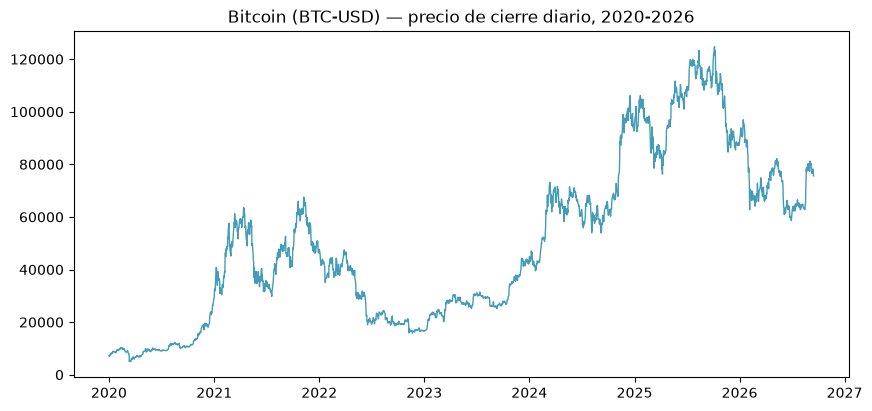

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(btc.index, btc.values, color="#449cb9", linewidth=1)
ax.set_title("Bitcoin (BTC-USD) — precio de cierre diario, 2020-2026")
plt.savefig("bitcoin_precio.png", dpi=110, bbox_inches="tight")
plt.show()

## Caidas, retornos y volatilidad

Bitcoin es la serie financiera mas volatil del curso, y merece mas que descargar el precio y pintarlo. Antes de llegar al Hampel Filter: sus caidas mas marcadas desde 2020 (*drawdowns*), sus retornos diarios y volatilidad movil -conectando con ARCH/GARCH (Modulos 09-10)-, y una comparacion de esa volatilidad con la del S&P 500 de la Leccion 01.

5 mayores caidas desde maximo acumulado (eventos distintos):
  2020-03-12  drawdown = -51.9%  precio = 4971 USD
  2021-07-20  drawdown = -53.1%  precio = 29807 USD
  2022-11-21  drawdown = -76.6%  precio = 15787 USD
  2023-09-11  drawdown = -62.8%  precio = 25163 USD
  2026-06-30  drawdown = -53.1%  precio = 58559 USD


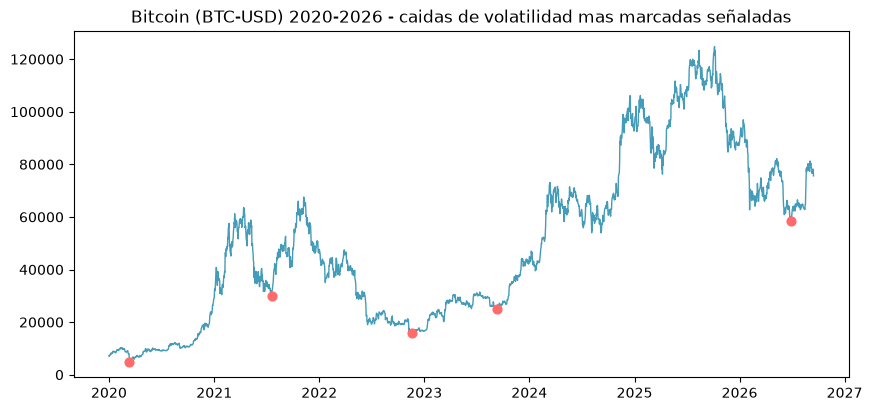

In [3]:
import pandas as pd

maximo_acumulado = btc.cummax()
drawdown = (btc - maximo_acumulado) / maximo_acumulado * 100  # en %

# minimos locales del drawdown, exigiendo eventos separados al menos 250 dias entre si
tmp = drawdown.copy()
picos = []
for _ in range(6):
    idx_min = tmp.idxmin()
    val_min = tmp.loc[idx_min]
    if val_min >= -15:
        break
    picos.append((idx_min, val_min))
    tmp.loc[idx_min - pd.Timedelta(days=250) : idx_min + pd.Timedelta(days=250)] = 0

picos = sorted(picos, key=lambda p: p[1])[:5]  # las 5 caidas mas profundas
picos = sorted(picos, key=lambda p: p[0])      # mostradas en orden cronologico
print("5 mayores caidas desde maximo acumulado (eventos distintos):")
for fecha, val in picos:
    print(f"  {fecha.date()}  drawdown = {val:.1f}%  precio = {btc.loc[fecha]:.0f} USD")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(btc.index, btc.values, color="#449cb9", linewidth=1)
for fecha, val in picos:
    ax.scatter([fecha], [btc.loc[fecha]], color="#ff6b6b", s=40, zorder=5)
ax.set_title("Bitcoin (BTC-USD) 2020-2026 - caidas de volatilidad mas marcadas señaladas")
plt.savefig("bitcoin_precio_drawdowns.png", dpi=110, bbox_inches="tight")
plt.show()


count    2449.000000
mean        0.145494
std         3.119217
min       -37.169539
25%        -1.277815
50%         0.032250
75%         1.484392
max        18.746474
Name: btc_usd, dtype: float64


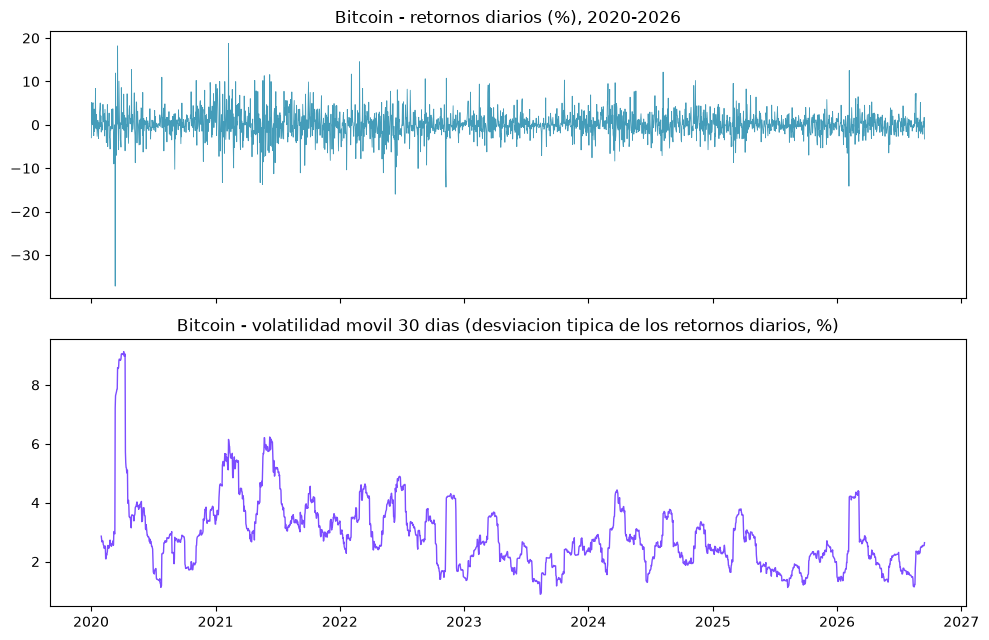

In [4]:
btc_ret = btc.pct_change().dropna() * 100
vol_30d = btc_ret.rolling(30).std()  # volatilidad movil, ventana de 30 dias
print(btc_ret.describe())

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(btc_ret.index, btc_ret.values, color="#449cb9", linewidth=0.6)
axes[0].set_title("Bitcoin - retornos diarios (%), 2020-2026")
axes[1].plot(vol_30d.index, vol_30d.values, color="#7c4dff", linewidth=1)
axes[1].set_title("Bitcoin - volatilidad movil 30 dias (desviacion tipica de los retornos diarios, %)")
plt.tight_layout()
plt.savefig("bitcoin_retornos_volatilidad.png", dpi=110, bbox_inches="tight")
plt.show()


In [5]:
abs_ret = btc_ret.abs()
autocorr_raw = [btc_ret.autocorr(lag) for lag in range(1, 6)]
autocorr_abs = [abs_ret.autocorr(lag) for lag in range(1, 6)]
print("autocorrelacion de los retornos (lags 1-5)   :", [round(v, 3) for v in autocorr_raw])
print("autocorrelacion del VALOR ABSOLUTO (lags 1-5):", [round(v, 3) for v in autocorr_abs])


autocorrelacion de los retornos (lags 1-5)   : [np.float64(-0.055), np.float64(0.042), np.float64(-0.02), np.float64(0.052), np.float64(0.005)]
autocorrelacion del VALOR ABSOLUTO (lags 1-5): [np.float64(0.143), np.float64(0.09), np.float64(0.065), np.float64(0.143), np.float64(0.099)]


Los retornos en si casi no tienen autocorrelacion (coherente con la Leccion 01 y la hipotesis de mercados eficientes: la **direccion** del proximo movimiento no se predice). Pero el **valor absoluto** de los retornos si muestra autocorrelacion positiva y sistematicamente mayor: un dia de movimiento grande (al alza o a la baja) tiende a ir seguido de otro dia de movimiento grande. Es la intuicion detras de un modelo ARCH/GARCH: no se modela el signo del retorno, se modela como su varianza depende de sus propios valores pasados.

In [6]:
import numpy as np
import yfinance as yf

spx = yf.download("^GSPC", start="2020-01-01", end="2026-09-16", interval="1d", threads=False)["Close"]
spx = spx.squeeze()
spx_ret = spx.pct_change().dropna() * 100

vol_anual_btc = btc_ret.std() * np.sqrt(365)  # Bitcoin cotiza los 365 dias del año
vol_anual_spx = spx_ret.std() * np.sqrt(252)  # el S&P 500 cotiza ~252 dias habiles

print(f"Bitcoin (BTC-USD): std diaria = {btc_ret.std():.3f}%  ->  volatilidad anualizada = {vol_anual_btc:.1f}%")
print(f"S&P 500 (^GSPC)  : std diaria = {spx_ret.std():.3f}%  ->  volatilidad anualizada = {vol_anual_spx:.1f}%")
print(f"Bitcoin es {vol_anual_btc / vol_anual_spx:.1f}x mas volatil que el S&P 500 en el mismo periodo")


[                       0%                       ]

[*********************100%***********************]  1 of 1 completed

Bitcoin (BTC-USD): std diaria = 3.119%  ->  volatilidad anualizada = 59.6%
S&P 500 (^GSPC)  : std diaria = 1.276%  ->  volatilidad anualizada = 20.3%
Bitcoin es 2.9x mas volatil que el S&P 500 en el mismo periodo


## El Hampel Filter

Un filtro de Hampel detecta atípicos usando una ventana móvil: para cada punto, calcula la mediana y la **MAD** (Median Absolute Deviation, una versión robusta de la desviación típica que no se deja arrastrar por los propios atípicos) de los `k` puntos a cada lado, y marca como atípico cualquier valor a más de `t0` desviaciones MAD de esa mediana local. Es más robusto que un filtro basado en media/desviación típica clásicas precisamente porque la mediana y la MAD no se disparan cuando hay un valor extremo en la ventana.

In [7]:
import numpy as np
import pandas as pd

def hampel_filter(serie, k=7, t0=3):
    """Devuelve (serie_filtrada, indices_atipicos). k = puntos a cada lado de la ventana."""
    x = serie.copy()
    L = 1.4826  # factor que hace que MAD sea comparable a la desviación típica en una normal
    rolling_median = x.rolling(2 * k + 1, center=True).median()
    mad = x.rolling(2 * k + 1, center=True).apply(
        lambda w: np.median(np.abs(w - np.median(w))), raw=True
    )
    threshold = t0 * L * mad
    diff = np.abs(x - rolling_median)
    outlier_idx = diff > threshold
    x_filtered = x.copy()
    x_filtered[outlier_idx] = rolling_median[outlier_idx]
    return x_filtered, outlier_idx

btc_filtrado, atipicos = hampel_filter(btc, k=7, t0=3)
print("nº de atípicos detectados:", int(atipicos.sum()), "de", len(btc), "observaciones")
btc[atipicos].sort_values(ascending=False).head(10)

nº de atípicos detectados: 41 de 2450 observaciones


Date
2025-08-13    123344.062500
2025-07-22    119995.414062
2025-06-09    110294.101562
2025-06-10    110257.234375
2025-06-05    101575.953125
2026-01-05     93882.554688
2026-01-06     93729.031250
2025-12-03     93527.804688
2025-12-01     86321.570312
2025-04-07     79235.335938
Name: btc_usd, dtype: float64

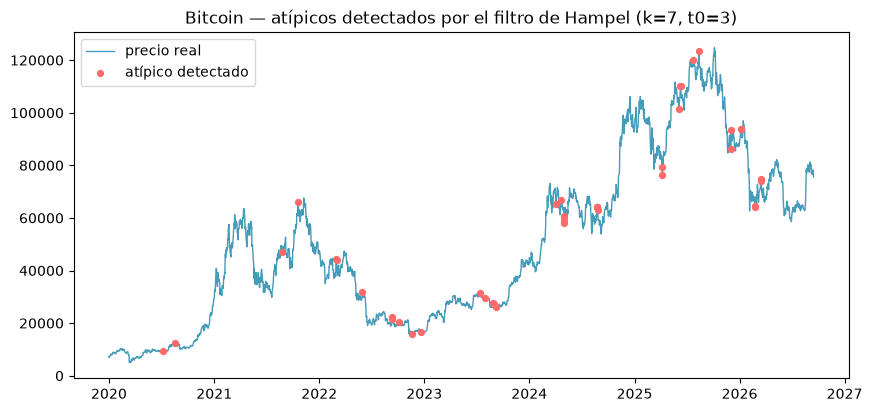

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(btc.index, btc.values, color="#449cb9", linewidth=1, label="precio real")
ax.scatter(btc.index[atipicos], btc.values[atipicos], color="#ff6b6b", s=18, zorder=5, label="atípico detectado")
ax.legend()
ax.set_title("Bitcoin — atípicos detectados por el filtro de Hampel (k=7, t0=3)")
plt.savefig("bitcoin_hampel.png", dpi=110, bbox_inches="tight")
plt.show()

## Lectura de los atípicos

Es importante no confundir "atípico estadístico" (un movimiento que se sale de la variabilidad local reciente) con "error de datos": en una serie tan volátil como Bitcoin, la mayoría de los puntos marcados por el filtro son movimientos de mercado reales y extremos (caídas o subidas de un solo día muy por encima de lo habitual en esa ventana), no errores de descarga. El Hampel Filter es una herramienta de **detección**, no de "limpieza automática de la verdad" — decidir si un atípico se corrige, se deja o se investiga aparte sigue siendo una decisión humana.

## Sensibilidad al parámetro `t0`

Cuantos menos desviaciones MAD se exijan (`t0` más bajo), más puntos se marcan como atípicos. Se compara con `t0=2` (más sensible) frente al `t0=3` de arriba.

In [9]:
_, atipicos_sensible = hampel_filter(btc, k=7, t0=2)
print("t0=3 (arriba):", int(atipicos.sum()), "atípicos")
print("t0=2 (más sensible):", int(atipicos_sensible.sum()), "atípicos")

t0=3 (arriba): 41 atípicos
t0=2 (más sensible): 112 atípicos


## Cierre

El precio de Bitcoin ya no depende de `coindeskr` (descontinuado): la descarga de Yahoo Finance funciona en vivo y de forma reproducible, verificado con los datos de arriba. El Hampel Filter identifica los movimientos más extremos de la serie sin dejarse arrastrar por ellos —al usar mediana y MAD en vez de media y desviación típica—, la misma técnica que se aplica también en R en esta misma lección con el paquete `pracma`.